## Kaushal AI EDA

### Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df = pd.read_csv('data/career_dataset_10k.csv')
df.head()

,user_id,education,experience_years,skills,interests,certification,target_career
0,c8322c2a,MBA,5,"['product management', 'business', 'excel']",['business'],NaN,Product Manager
1,c1349484,BSc,8,"['ui/ux', 'nodejs', 'cybersecurity', 'java']",['web development'],Google Data Analytics,Backend Developer
2,ea49041b,MCA,4,"['seo', 'html']",['marketing'],AWS Certification,Digital Marketer
3,f4240d3e,BTech,3,"['react', 'tableau']",['web development'],Azure Fundamentals,Web Developer
4,34981705,MCA,1,"['nodejs', 'sql', 'excel']",['web development'],Azure Fundamentals,Backend Developer


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_id           10000 non-null  str  
 1   education         10000 non-null  str  
 2   experience_years  10000 non-null  int64
 3   skills            10000 non-null  str  
 4   interests         10000 non-null  str  
 5   certification     8333 non-null   str  
 6   target_career     10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 547.0 KB


In [4]:
df.describe(include='all')

,user_id,education,experience_years,skills,interests,certification,target_career
count,10000,10000,10000.000000,10000,10000,8333,10000
unique,10000,6,NaN,7582,7,5,9
top,c8322c2a,BSc,NaN,"['machine learning', 'data analysis', 'sql', '...",['ai'],AWS Certification,Data Scientist
freq,1,1735,NaN,23,2809,1689,1214
mean,NaN,NaN,5.077500,NaN,NaN,NaN,NaN
std,NaN,NaN,3.167696,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,8.000000,NaN,NaN,NaN,NaN


In [5]:
# Check for missing values
df.isna().sum()

user_id                0
education              0
experience_years       0
skills                 0
interests              0
certification       1667
target_career          0
dtype: int64

In [6]:
df = df.drop(['user_id'],axis=1)
df.head()

,education,experience_years,skills,interests,certification,target_career
0,MBA,5,"['product management', 'business', 'excel']",['business'],NaN,Product Manager
1,BSc,8,"['ui/ux', 'nodejs', 'cybersecurity', 'java']",['web development'],Google Data Analytics,Backend Developer
2,MCA,4,"['seo', 'html']",['marketing'],AWS Certification,Digital Marketer
3,BTech,3,"['react', 'tableau']",['web development'],Azure Fundamentals,Web Developer
4,MCA,1,"['nodejs', 'sql', 'excel']",['web development'],Azure Fundamentals,Backend Developer


In [7]:
# Classification of columns into cat and num
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int','float']).columns
print(f"Categorical Columns: {cat_cols}")
print(f"Numerical Columns: {num_cols}")

# Unique values in cat columns
for col in cat_cols:
    print(f"{col}: {df[col].unique()[:5]}...")
    print(f"Value Counts: \n{df[col].value_counts()}")
    print("="*50)

Categorical Columns: Index(['education', 'skills', 'interests', 'certification', 'target_career'], dtype='str')
Numerical Columns: Index(['experience_years'], dtype='str')
education: <StringArray>
['MBA', 'BSc', 'MCA', 'BTech', 'Diploma']
Length: 5, dtype: str...
Value Counts: 
education
BSc        1735
BCA        1672
BTech      1666
MCA        1649
Diploma    1649
MBA        1629
Name: count, dtype: int64
skills: <StringArray>
[ '['product management', 'business', 'excel']',
 '['ui/ux', 'nodejs', 'cybersecurity', 'java']',
                              '['seo', 'html']',
                         '['react', 'tableau']',
                   '['nodejs', 'sql', 'excel']']
Length: 5, dtype: str...
Value Counts: 
skills
['machine learning', 'data analysis', 'sql', 'python']                                 23
['networking', 'cybersecurity']                                                        20
['nodejs', 'sql', 'java']                                                              19
['css

In [8]:
# Extract all skills present in dataset
all_skills = set()
for skills in df['skills']:
    for skill in skills.split(','):
        all_skills.add(skill.strip())
print(f"Total Unique Skills: {len(all_skills)}")
print(f"Sample Skills: {list(all_skills)[:10]}")

Total Unique Skills: 98
Sample Skills: ["'tableau']", "['data analysis']", "['tableau'", "['data analysis'", "'cloud computing'", "['content writing']", "'deep learning'", "['figma'", "['css'", "['seo'"]


#### Data Visualization Part 1

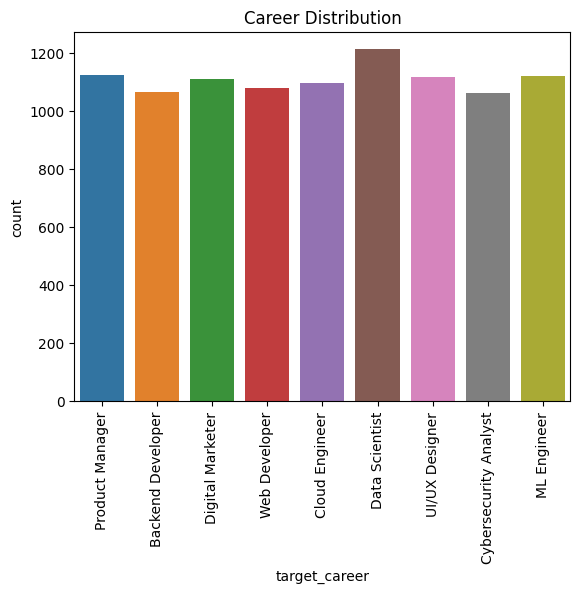

In [9]:
sns.countplot(x='target_career',data=df,hue='target_career')
plt.title("Career Distribution")
plt.xticks(rotation=90)
plt.show()

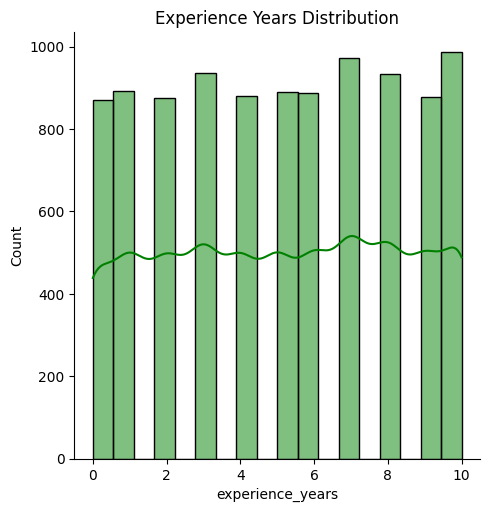

In [10]:
sns.displot(df['experience_years'], kde=True, color='green')
plt.title("Experience Years Distribution")
plt.show()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'MBA'),
  Text(1, 0, 'BSc'),
  Text(2, 0, 'MCA'),
  Text(3, 0, 'BTech'),
  Text(4, 0, 'Diploma'),
  Text(5, 0, 'BCA')])

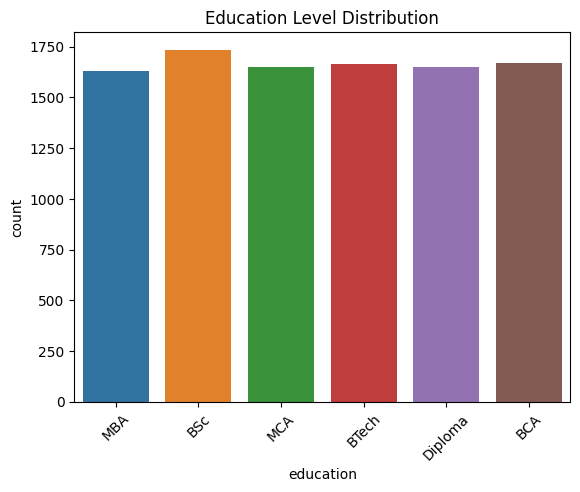

In [11]:
sns.countplot(x='education',data=df, hue='education')
plt.title("Education Level Distribution")
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Google Data Analytics'),
  Text(1, 0, 'AWS Certification'),
  Text(2, 0, 'Azure Fundamentals'),
  Text(3, 0, 'Coursera ML'),
  Text(4, 0, 'Udemy Web Dev')])

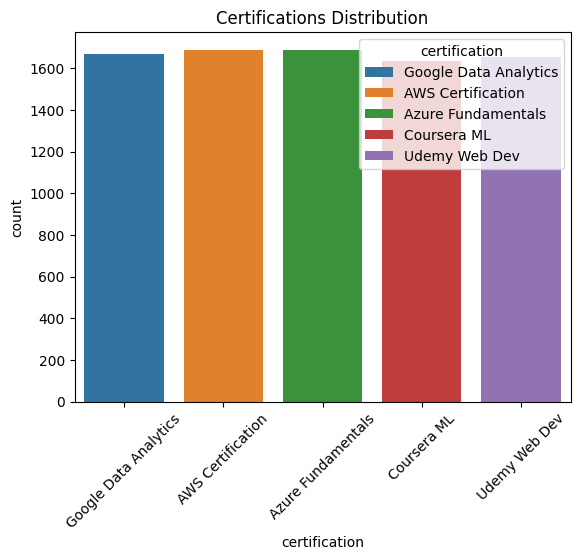

In [12]:
sns.countplot(x='certification',data=df, hue='certification')
plt.title("Certifications Distribution")
plt.xticks(rotation=45)

#### Data Preprocessing

In [13]:
# Fill missing values in certification with 'No Certification'
df['certification'] = df['certification'].fillna('No Certification')
df.isna().sum()

education           0
experience_years    0
skills              0
interests           0
certification       0
target_career       0
dtype: int64

In [14]:
# Remove '[]' from interests and contain only the interests
df['interests'] = df['interests'].str.strip('[]')
df['interests'] = df['interests'].str.replace("'", "")
df.head()

,education,experience_years,skills,interests,certification,target_career
0,MBA,5,"['product management', 'business', 'excel']",business,No Certification,Product Manager
1,BSc,8,"['ui/ux', 'nodejs', 'cybersecurity', 'java']",web development,Google Data Analytics,Backend Developer
2,MCA,4,"['seo', 'html']",marketing,AWS Certification,Digital Marketer
3,BTech,3,"['react', 'tableau']",web development,Azure Fundamentals,Web Developer
4,MCA,1,"['nodejs', 'sql', 'excel']",web development,Azure Fundamentals,Backend Developer


In [15]:
# Converting skills column data into a list of skills
import ast
df['skills'] = df['skills'].apply(ast.literal_eval)
df.head()

,education,experience_years,skills,interests,certification,target_career
0,MBA,5,"[product management, business, excel]",business,No Certification,Product Manager
1,BSc,8,"[ui/ux, nodejs, cybersecurity, java]",web development,Google Data Analytics,Backend Developer
2,MCA,4,"[seo, html]",marketing,AWS Certification,Digital Marketer
3,BTech,3,"[react, tableau]",web development,Azure Fundamentals,Web Developer
4,MCA,1,"[nodejs, sql, excel]",web development,Azure Fundamentals,Backend Developer


In [20]:
print(type(df['skills'].iloc[0]))

<class 'list'>


#### Feature Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer

In [22]:
# MultiLabelBinarizer for skills
mlb = MultiLabelBinarizer()
df_skills = mlb.fit_transform(df['skills'])
df_skills = pd.DataFrame(df_skills,columns=mlb.classes_)
df = pd.concat([df, df_skills], axis=1)
df = df.drop('skills', axis=1)
df.head()

,education,experience_years,interests,certification,target_career,aws,azure,business,c++,cloud computing,...,networking,nodejs,power bi,product management,python,react,seo,sql,tableau,ui/ux
0,MBA,5,business,No Certification,Product Manager,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,BSc,8,web development,Google Data Analytics,Backend Developer,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,MCA,4,marketing,AWS Certification,Digital Marketer,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,BTech,3,web development,Azure Fundamentals,Web Developer,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
4,MCA,1,web development,Azure Fundamentals,Backend Developer,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0


In [23]:
mlb.classes_

array(['aws', 'azure', 'business', 'c++', 'cloud computing',
       'content writing', 'css', 'cybersecurity', 'data analysis',
       'deep learning', 'digital marketing', 'excel', 'figma', 'html',
       'java', 'javascript', 'machine learning', 'networking', 'nodejs',
       'power bi', 'product management', 'python', 'react', 'seo', 'sql',
       'tableau', 'ui/ux'], dtype=object)

In [26]:
# OneHotEncoding for education, interest and certification
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = ohe.fit_transform(df[['education', 'interests', 'certification']])
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(['education', 'interests', 'certification']))
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(['education', 'interests', 'certification'], axis=1)
df.head()

,experience_years,target_career,aws,azure,business,c++,cloud computing,content writing,css,cybersecurity,...,interests_data,interests_design,interests_marketing,interests_security,interests_web development,certification_Azure Fundamentals,certification_Coursera ML,certification_Google Data Analytics,certification_No Certification,certification_Udemy Web Dev
0,5,Product Manager,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,8,Backend Developer,0,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,4,Digital Marketer,0,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,Web Developer,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1,Backend Developer,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   experience_years                     10000 non-null  int64  
 1   target_career                        10000 non-null  str    
 2   aws                                  10000 non-null  int64  
 3   azure                                10000 non-null  int64  
 4   business                             10000 non-null  int64  
 5   c++                                  10000 non-null  int64  
 6   cloud computing                      10000 non-null  int64  
 7   content writing                      10000 non-null  int64  
 8   css                                  10000 non-null  int64  
 9   cybersecurity                        10000 non-null  int64  
 10  data analysis                        10000 non-null  int64  
 11  deep learning                        100

In [28]:
# Label Encoding for target_career
le = LabelEncoder()
df['target_career'] = le.fit_transform(df['target_career'])
df.head()

,experience_years,target_career,aws,azure,business,c++,cloud computing,content writing,css,cybersecurity,...,interests_data,interests_design,interests_marketing,interests_security,interests_web development,certification_Azure Fundamentals,certification_Coursera ML,certification_Google Data Analytics,certification_No Certification,certification_Udemy Web Dev
0,5,6,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,8,0,0,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,4,4,0,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,8,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


#### Feature Engineering

In [ ]:
# Save the cleaned dataset and all the encoders for future use
import joblib
df.to_csv('data/cleaned_career_dataset.csv', index=False)
joblib.dump(mlb, 'demo_artifacts/skills_mlb.pkl')
joblib.dump(ohe, 'demo_artifacts/edu_interest_cert_ohe.pkl')
joblib.dump(le, 'demo_artifacts/target_career_le.pkl')
print("Data and encoders saved successfully!")